# Question 3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from matplotlib.colors import LogNorm
from scipy.stats import binned_statistic_2d
from scipy.stats import linregress
from sklearn.metrics import r2_score

## PART 1 AND 2
Plot a two-panel figure:

• (a) logarithmic density plot of RGal. vs. A(O), with a linear fit and legend;

• (b) residuals of the fit, RGal. vs. ∆A(O).

Use a python fitting tool to fit a linear function to the data, reporting the intercept and
slope with uncertainties. Include any hyperparameters used.

Intercept = 9.1278 ± 0.0002
Slope = -0.034196 ± 0.000015


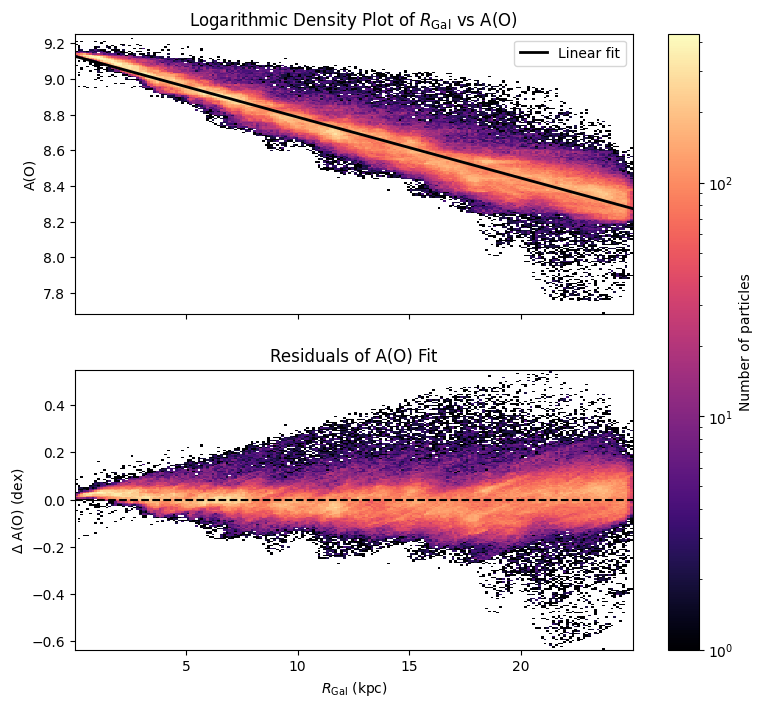

In [8]:
# Initialise data
file = "data/nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits"
data = fits.getdata(file, ext=1)
x = np.array(data["x"], dtype=float)
y = np.array(data["y"], dtype=float)
A_O = np.array(data["A_O"], dtype=float)
R_Gal = np.sqrt(x**2 + y**2)

# Calculate linear fit using Scipy linear regression
fit = linregress(R_Gal, A_O)
slope = fit.slope
intercept = fit.intercept
slope_unc = fit.stderr
intercept_unc = fit.intercept_stderr

# Calculate fitted A(O) and residuals
A_O_fit = slope * R_Gal + intercept
residuals = A_O - A_O_fit

# Create line of best fit
R_line = np.linspace(0, 25, 200)
A_O_fit_line = slope * R_line + intercept

# Create the two-panel figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 8), sharex=True)

# Plot 1 - Logarithmic density plot of RGal. vs. A(O)
density_plot = ax1.hist2d(R_Gal, A_O, bins=200, norm=LogNorm(), cmap="magma")
ax1.plot(R_line, A_O_fit_line, color="black", linewidth=2, label="Linear fit") #linear fit 
ax1.set_title(r"Logarithmic Density Plot of $R_{\rm Gal}$ vs A(O)")
ax1.set_ylabel("A(O)")

# Plot 2 - Residuals of fit
residual_density = ax2.hist2d(R_Gal, residuals, bins=200, norm=LogNorm(), cmap="magma")
ax2.axhline(0, color="black", linestyle="--") # Zero line
ax1.legend()
ax2.set_xlabel(r"$R_{\rm Gal}$ (kpc)")
ax2.set_ylabel(r"$\Delta$ A(O) (dex)")
ax2.set_title(r"Residuals of A(O) Fit")

# Add colourbar
colourbar = fig.colorbar(density_plot[3], ax=[ax1, ax2])
colourbar.set_label("Number of particles")

# Report intercept and slope with uncertainties
print(f"Intercept = {intercept:.4f} ± {intercept_unc:.4f}")
print(f"Slope = {slope:.6f} ± {slope_unc:.6f}")


## PART 3

Discuss where the linear model fits well and where it does not. Use statistical met
rics, such as the root mean square or another goodness-of-fit indicator, to quantify its
performance overall and in regions with larger residuals

In [4]:
def calculate_metrics(lower_lim, upper_lim):
    # Calculate root mean square and r squared within a region
    region = ((R_Gal >= lower_lim) & (R_Gal < upper_lim))
    root_mean_square = np.sqrt(np.mean(residuals[region]**2))
    r_squared = r2_score(A_O[region], A_O_fit[region])

    # Print results
    print(f"REGION: {lower_lim} kpc to {upper_lim} kpc")
    print(f"Root mean square = {root_mean_square:.4f} dex, R squared = {r_squared:.4f} dex")

calculate_metrics(0, 25)
calculate_metrics(0, 5)
calculate_metrics(5, 10)
calculate_metrics(10, 15)
calculate_metrics(15, 20)
calculate_metrics(20, 25)


REGION: 0 kpc to 25 kpc
Root mean square = 0.0726 dex, R squared = 0.9125 dex
REGION: 0 kpc to 5 kpc
Root mean square = 0.0323 dex, R squared = 0.6565 dex
REGION: 5 kpc to 10 kpc
Root mean square = 0.0483 dex, R squared = 0.5581 dex
REGION: 10 kpc to 15 kpc
Root mean square = 0.0704 dex, R squared = 0.2865 dex
REGION: 15 kpc to 20 kpc
Root mean square = 0.0879 dex, R squared = 0.2220 dex
REGION: 20 kpc to 25 kpc
Root mean square = 0.0866 dex, R squared = 0.1427 dex


The linear model fits best at lower radius where the residuals are the smallest. This is seen in the root mean squared values as below a radius of 10 kpc, the root mean square value is below 0.05. As the radius increase, the root mean square value increases to values of approximately 0.7-0.8 which is expected as there is larger scatter observed in the plot and thus larger residuals. Thus, the linear model fits the inner galaxy well but fits the outer galaxy less well.


## PART 4
Plot a three-panel figure for the x vs. y plane using the same bins and sensible colormaps:

• (a) 2D histogram of the median simulated A(O);

• (b) 2D histogram of the median fitted A(O);

• (c) 2D histogram of the median residuals ∆A(O).

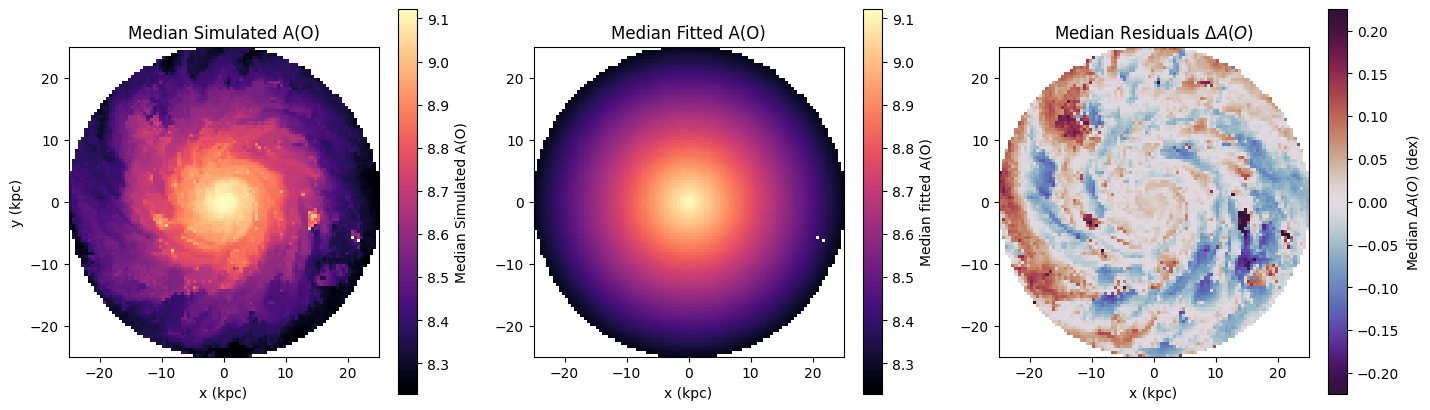

In [9]:
def A_O_histograms(n_bins):

    # Binned_statistic_2d is used to calculate the median value in each x-y bin
    # Median simulated A(O) in each bin
    median_simulated = binned_statistic_2d(x, y, A_O, statistic="median", bins=n_bins)
    # Median fitted A(O) in each bin
    median_fitted = binned_statistic_2d(x, y, A_O_fit, statistic="median", bins=n_bins)
    # Median residual in each bin
    median_residuals = binned_statistic_2d(x, y, residuals, statistic="median", bins=n_bins)

    # Use central 98% of the values for A(O) colour bar
    A_O_min = np.percentile(A_O, 1)
    A_O_max = np.percentile(A_O, 99)

    # Use central 98% of the values for residual colour bar
    residual_min = np.percentile(residuals, 1)
    residual_max = np.percentile(residuals, 99)
    # Takes the largest absolute value between the min and max residual
    max_residual_value = max(abs(residual_min), abs(residual_max))
    # Uses largest value to define range of colour bar so that its centered around 0
    residual_min = -max_residual_value
    residual_max = max_residual_value

    # Create the three-panel figure
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    # Define range of plots: -25 <= x, y <= 25
    range = [-25, 25, -25, 25]

    # .statistic returns the median values in each bin
    # Need to transpose the result from binned_statistic_2d using .T because imshow
    # plots (y, x) while binned_statistic_2d returns values as (x, y).

    # Plot 1 - Median simulated A(O) with colourbar
    panel_a = axes[0].imshow(median_simulated.statistic.T, origin="lower", cmap="magma", 
                            vmin=A_O_min, vmax=A_O_max, extent=range)
    axes[0].set_title("Median Simulated A(O)")
    axes[0].set_ylabel("y (kpc)")
    axes[0].set_xlabel("x (kpc)")
    colourbar1 = fig.colorbar(panel_a, ax=axes[0])
    colourbar1.set_label("Median Simulated A(O)")

    # Plot 2 - Median fitted A(O) with colourbar
    panel_b = axes[1].imshow(median_fitted.statistic.T, origin="lower", cmap="magma", 
                            vmin=A_O_min, vmax=A_O_max, extent=range)
    axes[1].set_title("Median Fitted A(O)")
    axes[1].set_xlabel("x (kpc)")
    colourbar2 = fig.colorbar(panel_b, ax=axes[1])
    colourbar2.set_label("Median fitted A(O)")

    # Plot 3 - Median residuals with colourbar
    panel_c = axes[2].imshow(median_residuals.statistic.T, origin="lower", cmap="twilight_shifted", 
                            vmin=residual_min, vmax=residual_max, extent=range)
    axes[2].set_title(r"Median Residuals $\Delta A(O)$")
    axes[2].set_xlabel("x (kpc)")
    colourbar3 = fig.colorbar(panel_c, ax=axes[2])
    colourbar3.set_label(r"Median $\Delta A(O)$ (dex)")

    # Save figure
    plt.savefig(f"figures/A_O_histograms_{n_bins}_bins.png")
    plt.show()

A_O_histograms(100)

## PART 5
Describe your choice of 2D bins. Discuss what details would be missed with fewer bins
and what problems could arise with more bins.

I used 100 bins across the x and y axes (100 x  100 = 10000 total bins) and each bin has a width of 0.5 kpc x 0.5 kpc. 

Using fewer bins causes the plots to smooth out a lot of the internal structure, which means that the small-scale variations are lost and only the large scale features are visible. 

Using too many bins means that some bins will end up having very few data points or no data points which
causes some bins to be blank.

When too many bins are used, there are some bins that either have very little data or don't have any data in them. These blank spots make the plot appear patchy.  

I plotted 3 different choices for the number of bins to visualise this:

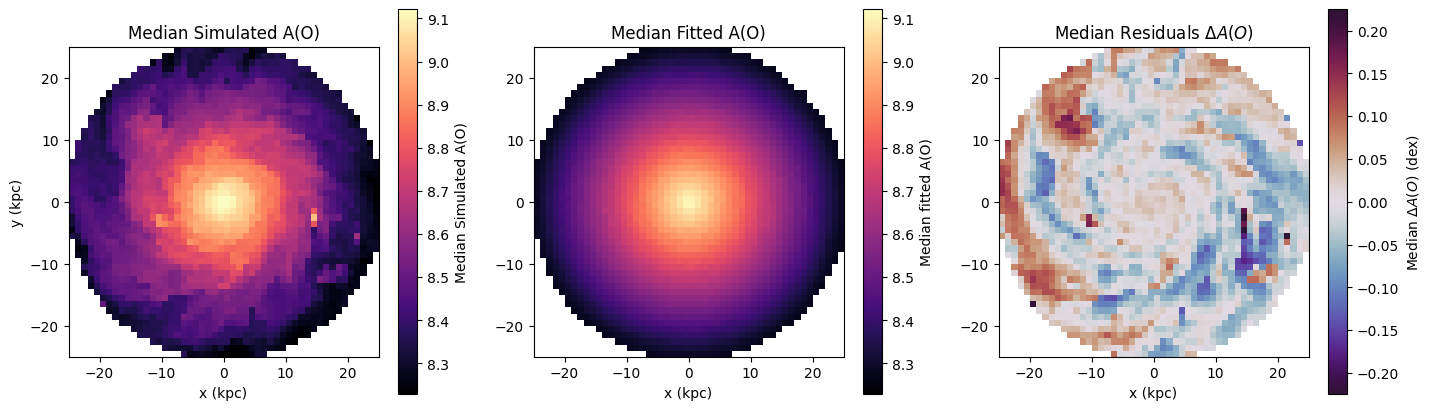

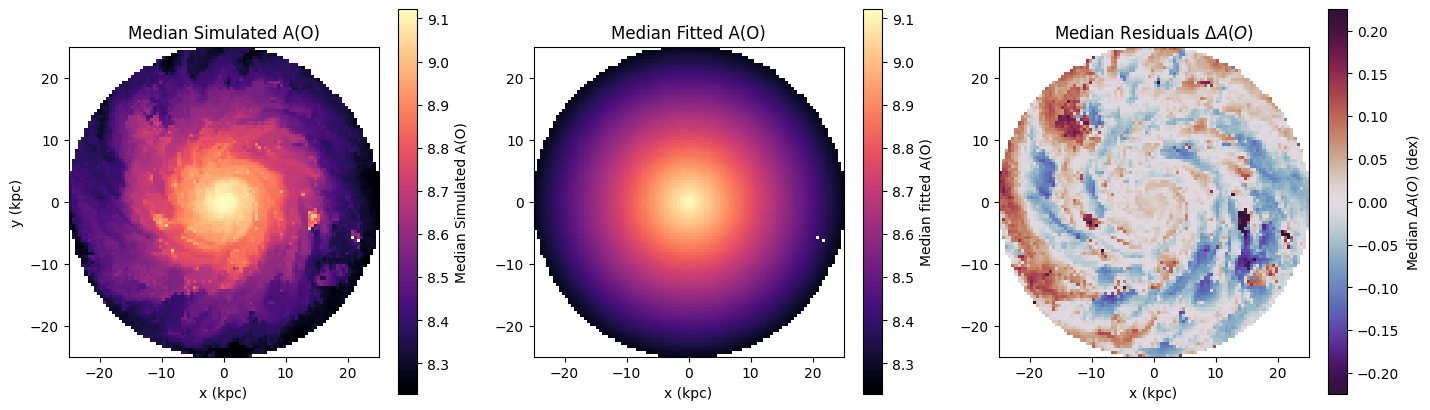

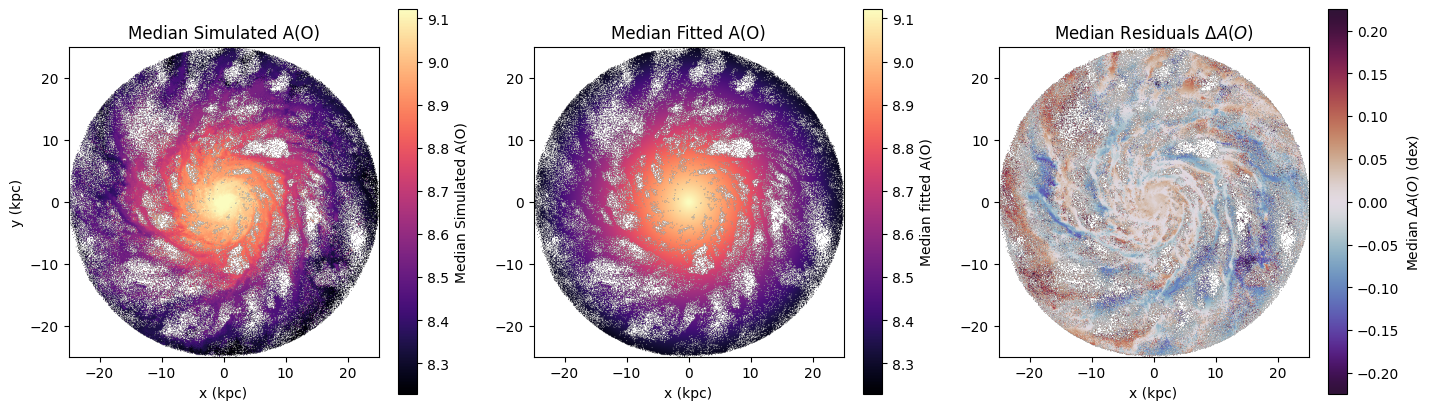

In [10]:
A_O_histograms(50)
A_O_histograms(100)
A_O_histograms(500)

## PART 6
Analyse the residuals in more detail and propose a reasonable physical explanation for
any patterns you observe.

Near the centre of the galaxy the residuals are close to 0 which indicates that the gas is at 0 metallicity. However, as we approach the outer galaxy, the residuals increase. Red regions indicate that the gas is more metal-rich than expected and blue regions indicate that the gas is more metal-poor than expected. These variations in the residuals occur in clumps and are not due to random noise, indicating that there is some physical meaning behind it. 

One physical explanation for this is that the pattern in the residuals shows us the spiral arms of the galaxy which are more metal rich (red) whereas the parts between the spiral arms are metal poor (blue). The larger residuals at the outer part of the galaxy may also be because gas mixing is less efficient at the outskirts of a galaxy.